# TSTORMS Tutorial

This notebook works through a complete TCTrack workflow using
[TSTORMS](https://github.com/Cambridge-ICCS/TSTORMS) to detect and track
tropical cyclones in ERA5 reanalysis data.

We start by installing the tracker, then obtain and preprocess the example data,
run the tracking, and finally visualise the resulting tracks.

## Installing TSTORMS

First we need to install the underlying TSTORMS software.

This requires GNU make, a Fortran compiler (gfortran is assumed, though others are
possible) and NetCDF with Fortran bindings.
If these are not included on your system and you are using conda they can be installed with:
```
conda install -c conda-forge gfortran make netcdf-fortran
```

To install TSTORMS we use the
[`install_tstorms.sh`](https://github.com/Cambridge-ICCS/TCTrack/blob/main/tutorial/install_tstorms.sh)
script, which will clone and build TSTORMS locally under the tutorial
directory. Read the script carefully to understand and check that you are
happy with what it will do before running the cell.

In [1]:
import subprocess

subprocess.run(["./install_tstorms.sh"], check=True)

TSTORMS is already installed, skipping installation.


CompletedProcess(args=['./install_tstorms.sh'], returncode=0)

## Obtaining Data

We will use example data from the ERA5 reanalysis dataset from 1950-09-01 to
1950-09-07.

The following cell downloads a pre-prepared bundle from the TCTrack GitHub
releases and extracts the NetCDF files into a `data/` directory using the
`fetch_data` function from `fetch_data.py`.

The data can alternatively be downloaded from the [Copernicus Climate Data
Store](https://cds.climate.copernicus.eu). There is another function in
`fetch_data.py` to do this, but this requires an account and API key.

In [2]:
from fetch_data import fetch_data

fetch_data()

Done.


## Preprocessing of Data

The data now needs to be preprocessed into the form [required by
TSTORMS](https://tctrack.readthedocs.io/en/latest/tracking-algorithms/tstorms.html#input-data).
This will be done here using the [preprocessing helper
functions](https://tctrack.readthedocs.io/en/latest/api/preprocessing_api.html).

The preprocessed data will be put in `data_processed/`.

We need the following variables:

* Surface (10m) wind components
* Vorticity at 850 hPa
* Mean sea-level pressure
* Mean temperature over 500-200 hPa

All of these are already included in the downloaded data, except for the mean temperature which must be calculated.

Each variable must also be in its own file with specific variable / coordinate names, an unlimited time dimension,
updated time units (so the values are not negative) and an ascending latitude. We can create a helper function
(`preprocess_tstorms_input`) to do this.

In [3]:
import os

import cf

from tctrack import preprocessing

# Specify file structure
data_in_dir = "data"
data_dir = "data_processed"
os.makedirs(data_dir, exist_ok=True)


def preprocess_tstorms_input(
    field: str | cf.Field, nc_name: str, output_file: str
) -> None:
    """Update the dimensions and netcdf metadata, then write to a file."""
    # Remove any size-1 dimensions
    field = preprocessing.squeeze_field(field)
    # Change time units so there are no negative values
    field = preprocessing.set_time_units(field, "days since 1950-01-01")
    # Flip latitude so it is ascending
    field = preprocessing.flip_axis(field, "Y")
    # Update the netcdf metadata and write to file
    preprocessing.set_netcdf_info(
        field,
        nc_name=nc_name,
        output_file=output_file,
        coord_nc_names={"time": "time", "latitude": "lat", "longitude": "lon"},
        axis_unlimited="T",
    )

Write the sea-level pressure and surface wind components to the output
directory in separate files.

In [4]:
field_u10, field_v10, field_msl = preprocessing.separate_variables(
    f"{data_in_dir}/era5_sfc.nc",
    output_files={},
    return_order=["u10", "v10", "msl"],
)
preprocess_tstorms_input(field_msl, "slp", f"{data_dir}/slp.nc")
preprocess_tstorms_input(field_u10, "u_ref", f"{data_dir}/u_ref.nc")
preprocess_tstorms_input(field_v10, "v_ref", f"{data_dir}/v_ref.nc")
del field_msl, field_u10, field_v10  # free memory

Then the vorticity at 850 hPa.

In [5]:
preprocess_tstorms_input(
    f"{data_in_dir}/era5_vo.nc", "vort850", f"{data_dir}/vort850.nc"
)

Finally, take a mean over pressure levels of the temperature and write it to
the output directory.

In [6]:
field_t = preprocessing.collapse_field(f"{data_in_dir}/era5_t.nc", "mean", axes="Z")
preprocess_tstorms_input(field_t, "tm", f"{data_dir}/tm.nc")
del field_t  # free memory

## Running the code

TSTORMS involves two steps:
1) Detection - Identifying tropical storm candidates at each timestep.
2) Stitching - Combining these into tracks and filtering.

Refer to the
[TSTORMS page](https://tctrack.readthedocs.io/en/latest/tracking-algorithms/tstorms.html)
in the documentation for further information about what is going on in these steps.

We first need to set up the base parameters (the location of the TSTORMS installation, and the input / output directories) using
[TSTORMSBaseParameters](https://tctrack.readthedocs.io/en/latest/api/tstorms_api.html#tctrack.tstorms.TSTORMSBaseParameters),
as well as the parameters for both detection and stitching using
[TSTORMSDetectParameters](https://tctrack.readthedocs.io/en/latest/api/tstorms_api.html#tctrack.tstorms.TSTORMSDetectParameters)
and
[TSTORMSStitchParameters](https://tctrack.readthedocs.io/en/latest/api/tstorms_api.html#tctrack.tstorms.TSTORMSStitchParameters).
These can be specified manually, but here we will use the `"default"` parameter set (provided by the 
[`parameter_set`](https://tctrack.readthedocs.io/en/latest/api/tstorms_api.html#tctrack.tstorms.parameter_set)
function) which follows the
[[Vitart2001]](https://tctrack.readthedocs.io/en/latest/references.html#vitart2001)
paper.


In [7]:
from tctrack import tstorms

tstorms_params, detect_params, stitch_params = tstorms.parameter_set(
    "default",
    tstorms_dir=f"{os.getcwd()}/TSTORMS",
    output_dir="tstorms_outputs",
)

Finally, we create the TSTORMS tracker object with our defined parameters and
run the tracker over the preprocessed input files. Saving the results to `tracks_tstorms.nc`.


In [8]:
# Define and run the tracker
tstorms_tracker = tstorms.TSTORMSTracker(tstorms_params, detect_params, stitch_params)

input_files = [
    f"{data_dir}/u_ref.nc",
    f"{data_dir}/v_ref.nc",
    f"{data_dir}/vort850.nc",
    f"{data_dir}/tm.nc",
    f"{data_dir}/slp.nc",
]
tstorms_tracker.run_tracker(input_files, "tracks_tstorms.nc")

Executing Detect...
Detect completed successfully.
First 12 lines of output:
         
 /home/sam/rse/tctrack/main/tutorial/data_processed/u_ref.nc
 /home/sam/rse/tctrack/main/tutorial/data_processed/v_ref.nc
 /home/sam/rse/tctrack/main/tutorial/data_processed/vort850.nc
 /home/sam/rse/tctrack/main/tutorial/data_processed/tm.nc
 /home/sam/rse/tctrack/main/tutorial/data_processed/slp.nc
         
  imx, jmx, nmx =         1440         721          28
         
    
  year, month, day, hour =         1950           9           1           0
    

...

Last 12 lines of output:
    
  year, month, day, hour =         1950           9           7           6
    
        1950           9           7           6          10
    
  year, month, day, hour =         1950           9           7          12
    
        1950           9           7          12           8
    
  year, month, day, hour =         1950           9           7          18
    
        1950           9           7   

## Inspecting the output

The output file is a CF-NetCDF file containing the tracks, along with variables such
as wind speed and sea-level pressure along each track. The structure can be inspected
with `ncdump -h tracks_tstorms.nc`, or read directly with cf-python:


In [9]:
tracks = cf.read("tracks_tstorms.nc")
tracks

[<CF Field: air_pressure_at_mean_sea_level(trajectory(3), observation(21)) Pa>,
 <CF Field: atmosphere_relative_vorticity(trajectory(3), observation(21)) s**-1>,
 <CF Field: wind_speed(trajectory(3), observation(21)) m s**-1>]

In [10]:
for field in tracks:
    print(f"{field.long_name}: {field.shape}")

Mean sea level pressure: (3, 21)
Vorticity (relative): (3, 21)
Surface Wind Speed: (3, 21)


## Visualising Results

Finally we can visualise the results by plotting the tracks on a map.

In [11]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np

# Extract the wind speed field and its coordinates as arrays
wind_field = tracks.select_field("wind_speed")
lats = wind_field.coordinate("latitude").array
lons = wind_field.coordinate("longitude").array
times = wind_field.coordinate("time").dtarray
intensity = wind_field.array

# Get intensity metadata for labels
intensity_name = wind_field.get_property("long_name")
intensity_units = wind_field.get_property("units")
min_intensity = np.nanmin(intensity)
max_intensity = np.nanmax(intensity)

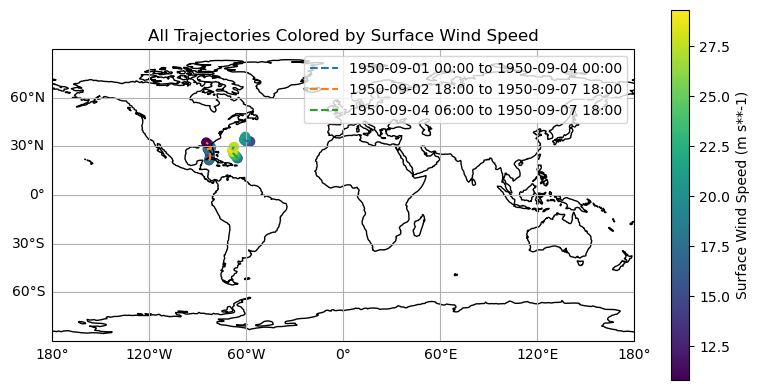

In [12]:
plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, 90])
ax.coastlines()
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True
gl.bottom_labels = True

# Plot each trajectory
for i in range(lats.shape[0]):
    times_i = times[i].compressed()
    label = (
        f"{times_i[0].strftime('%Y-%m-%d %H:%M')} to "
        f"{times_i[-1].strftime('%Y-%m-%d %H:%M')}"
    )
    mask = np.isfinite(lons[i])
    pl = ax.plot(
        lons[i, mask],
        lats[i, mask],
        "--",
        transform=ccrs.PlateCarree(),
        label=f"{label}",
    )
    sc = ax.scatter(
        lons[i],
        lats[i],
        c=intensity[i],
        cmap="viridis",
        s=40,
        vmin=min_intensity,
        vmax=max_intensity,
        transform=ccrs.PlateCarree(),
    )

plt.colorbar(sc, label=f"{intensity_name} ({intensity_units})")
plt.title(f"All Trajectories Colored by {intensity_name}")
plt.legend()
plt.tight_layout()
plt.show()